In [13]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from pathlib import Path

In [14]:
# gradient descent minimises MSE loss

class OLS_GradientDescent:
    def __init__(self):
        self.coef_ = None
        self.loss_history_ = None

    def fit(self, X, y, learning_rate=0.01, n_iterations=1_000_000):

        self.loss_history_ = []
        
        n_samples, n_features = X.shape
        self.coef_ = np.zeros(n_features)

        for _ in range(n_iterations):
            y_pred = X @ self.coef_
            residuals = (y-y_pred)

            loss = np.mean(residuals ** 2)
            self.loss_history_.append(loss)

            gradient = (-2/n_samples) * X.T @ residuals
            self.coef_ -= learning_rate * gradient

        return self

    def predict(self,X):
        if self.coef_ is None:
           raise ValueError("Model has not been fitted.")
        return X @ self.coef_

    


In [15]:
df = sm.datasets.longley.load_pandas().data


y = df["TOTEMP"].to_numpy()
X = df.drop(columns="TOTEMP").to_numpy()
X = np.column_stack((
    np.ones(len(X)),
    X
))
print(X.shape)
print(y.shape)

(16, 7)
(16,)


In [16]:
print("X min/max:", np.nanmin(X), np.nanmax(X))
print("y min/max:", np.nanmin(y), np.nanmax(y))

print("NaN in X:", np.isnan(X).any())
print("NaN in y:", np.isnan(y).any())

print("Inf in X:", np.isinf(X).any())
print("Inf in y:", np.isinf(y).any())

X min/max: 1.0 554894.0
y min/max: 60171.0 70551.0
NaN in X: False
NaN in y: False
Inf in X: False
Inf in y: False


In [17]:
X_mean = X[:, 1:].mean(axis=0)
X_std = X[:, 1:].std(axis=0)

X_scaled = X.copy().astype(float)
X_scaled[:, 1:] = (X[:, 1:] - X_mean) / X_std

y_mean = y.mean()
y_std = y.std()

y_scaled = (y - y_mean) / y_std

In [18]:
GD = OLS_GradientDescent()
GD.fit(X_scaled,y_scaled)
print(GD.coef_)
print(GD.predict(X_scaled))

[ 2.27248775e-17  4.61387556e-02 -1.01287895e+00 -5.37428703e-01
 -2.04721647e-01 -1.01551307e-01  2.47918705e+00]
[-1.54725156 -1.20602631 -1.52694729 -1.09392459 -0.70742303 -0.42013318
 -0.0482493  -0.45372887  0.20225732  0.613023    0.84376154  0.36319468
  1.02740486  1.27414216  1.07987907  1.60002151]


In [19]:
beta_scaled = GD.coef_
beta_original = np.empty_like(beta_scaled)

# slopes
beta_original[1:] = (
    y_std * beta_scaled[1:] / X_std
)

# intercept
beta_original[0] = (
    y_mean
    + y_std * beta_scaled[0]
    - X_mean @ beta_original[1:]
)

print(beta_original)

[-3.48155962e+06  1.50152479e+01 -3.57885310e-02 -2.01980183e+00
 -1.03313076e+00 -5.12708122e-02  1.82879936e+03]


In [20]:
print("first loss:", GD.loss_history_[0])
print("last loss:", GD.loss_history_[-1])

print(GD.loss_history_[-20:])

first loss: 0.9999999999999999
last loss: 0.0045209958457955385
[np.float64(0.004520995845916672), np.float64(0.004520995845910295), np.float64(0.004520995845903935), np.float64(0.004520995845897557), np.float64(0.004520995845891173), np.float64(0.004520995845884797), np.float64(0.004520995845878412), np.float64(0.004520995845872045), np.float64(0.004520995845865657), np.float64(0.004520995845859294), np.float64(0.004520995845852904), np.float64(0.0045209958458465255), np.float64(0.0045209958458401625), np.float64(0.004520995845833784), np.float64(0.004520995845827415), np.float64(0.004520995845821035), np.float64(0.004520995845814673), np.float64(0.004520995845808279), np.float64(0.004520995845801919), np.float64(0.0045209958457955385)]


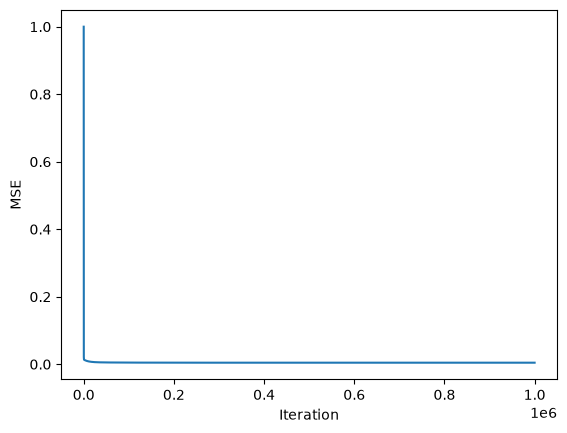

In [21]:
import matplotlib.pyplot as plt

plt.plot(GD.loss_history_)
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.show()

In [22]:
yhat_gd = X @ beta_original
yhat_closed = X @ beta_closed

print("Prediction difference:")
print(np.linalg.norm(yhat_gd - yhat_closed))

print("GD RSS:")
print(np.sum((y - yhat_gd)**2))

print("OLS RSS:")
print(np.sum((y - yhat_closed)**2))

NameError: name 'beta_closed' is not defined